In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from rake_nltk import Rake
import nltk
import matplotlib.pyplot as plt

# Loading to db
# importing os module for environment variables
import os
# importing necessary functions from dotenv library
from dotenv import load_dotenv 
# loading variables from .env file
load_dotenv() 
import psycopg2
from sqlalchemy import create_engine

# Larger Pull Clinical Trials

In [3]:
ct_df = pd.read_csv("/Users/shantibrodnick/Downloads/510Capstone/GenderDisparityinResearch/data/raw/raw_clinical_trials_data.csv")

In [34]:
ct_df.info()
# 373,282 rows

<class 'pandas.DataFrame'>
RangeIndex: 373282 entries, 0 to 373281
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   nct_number       373282 non-null  str           
 1   title            373282 non-null  str           
 2   study_status     373282 non-null  str           
 3   summary          373282 non-null  str           
 4   conditions       373280 non-null  str           
 5   pom              363741 non-null  str           
 6   sponsor          373282 non-null  str           
 7   collaborators    125975 non-null  str           
 8   sex              373122 non-null  str           
 9   age              373282 non-null  str           
 10  enrollment       370212 non-null  float64       
 11  funder_type      373282 non-null  str           
 12  study_type       373282 non-null  str           
 13  start_date       373282 non-null  datetime64[us]
 14  completion_date  365288 non-nul

## date EDA 

In [5]:
ct_df['start_date'] = pd.to_datetime(ct_df['start_date'])
ct_df['completion_date'] = pd.to_datetime(ct_df['completion_date'])

In [6]:
ct_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 373282 entries, 0 to 373281
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   nct_number       373282 non-null  str           
 1   title            373282 non-null  str           
 2   study_status     373282 non-null  str           
 3   summary          373282 non-null  str           
 4   conditions       373280 non-null  str           
 5   pom              363741 non-null  str           
 6   sponsor          373282 non-null  str           
 7   collaborators    125975 non-null  str           
 8   sex              373122 non-null  str           
 9   age              373282 non-null  str           
 10  enrollment       370212 non-null  float64       
 11  funder_type      373282 non-null  str           
 12  study_type       373282 non-null  str           
 13  start_date       373282 non-null  datetime64[us]
 14  completion_date  365288 non-nul

In [7]:
ct_df['start_year'] = ct_df['start_date'].dt.year
ct_df['completion_year'] = ct_df['completion_date'].dt.year

In [8]:
ct_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 373282 entries, 0 to 373281
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   nct_number       373282 non-null  str           
 1   title            373282 non-null  str           
 2   study_status     373282 non-null  str           
 3   summary          373282 non-null  str           
 4   conditions       373280 non-null  str           
 5   pom              363741 non-null  str           
 6   sponsor          373282 non-null  str           
 7   collaborators    125975 non-null  str           
 8   sex              373122 non-null  str           
 9   age              373282 non-null  str           
 10  enrollment       370212 non-null  float64       
 11  funder_type      373282 non-null  str           
 12  study_type       373282 non-null  str           
 13  start_date       373282 non-null  datetime64[us]
 14  completion_date  365288 non-nul

In [ ]:
# Find min and max year
print(ct_df['start_year'].min()) # 1948
print(ct_df['completion_year'].max()) # 2100

1948
2100.0


In [8]:
print(ct_df['completion_year'].head())
print(ct_df['start_year'].head())

0    1987.0
1    2040.0
2    1994.0
3    1989.0
4    1991.0
Name: completion_year, dtype: float64
0    1982
1    1983
2    1983
3    1983
4    1983
Name: start_year, dtype: int32


In [9]:
ct_df['completion_year'] = ct_df['completion_year'].astype('Int64')

In [10]:
print(ct_df['completion_year'].head())

0    1987
1    2040
2    1994
3    1989
4    1991
Name: completion_year, dtype: Int64


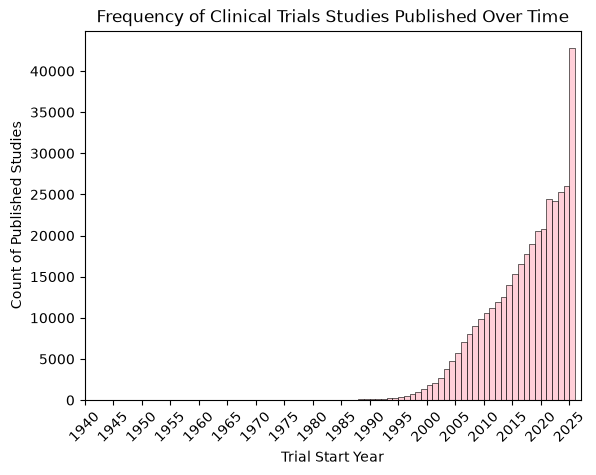

In [61]:
sns.histplot(ct_df, x = 'start_year', binwidth=1, color='pink')
plt.xlim(1940, 2027)
plt.xticks(np.arange(1940, 2027, step = 5), rotation=45)
plt.xlabel("Trial Start Year")
plt.ylabel("Count of Published Studies")
plt.title("Frequency of Clinical Trials Studies Published Over Time")
plt.show()

<Axes: xlabel='completion_year', ylabel='Count'>

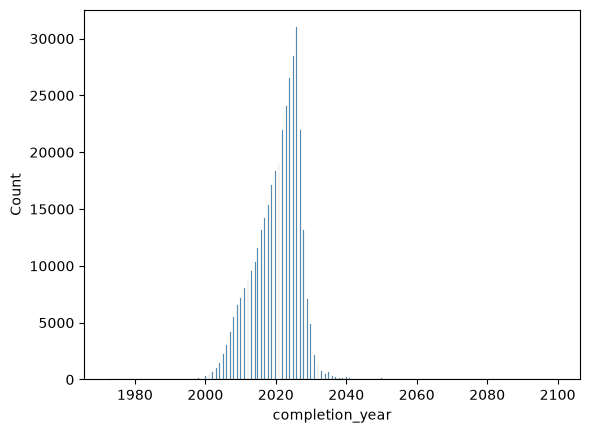

In [12]:
sns.histplot(ct_df, x = 'completion_year')

## pom EDA 

In [32]:
ct_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 373282 entries, 0 to 373281
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   nct_number       373282 non-null  str           
 1   title            373282 non-null  str           
 2   study_status     373282 non-null  str           
 3   summary          373282 non-null  str           
 4   conditions       373280 non-null  str           
 5   pom              363741 non-null  str           
 6   sponsor          373282 non-null  str           
 7   collaborators    125975 non-null  str           
 8   sex              373122 non-null  str           
 9   age              373282 non-null  str           
 10  enrollment       370212 non-null  float64       
 11  funder_type      373282 non-null  str           
 12  study_type       373282 non-null  str           
 13  start_date       373282 non-null  datetime64[us]
 14  completion_date  365288 non-nul

In [ ]:
ct_df['pom'].isna().sum()
# 9541
# pom stands for primary outcome measures

np.int64(9541)

In [ ]:
# Try using rake for keyword extraction

In [66]:
ct_df['pom'].iloc[1]

'Lead related complications for each lead model., All follow-up visits will be utilized in the analyses. This is an observational study that does not have a statistically powered primary hypothesis. Therefore, a specific study sample size is not applicable., Ongoing: Implant to the cardiac lead is terminated from the study if the patient exit, patient death, or out-of-service (e.g. deactivated/inactive).'

In [ ]:
ct_df['pom'].iloc[230]

'Response rate, no evidence of leukemia as judged by two peripheral blood smears and two bone marrow aspirates and biopsies. Disease-free and overall survival data will be computed from the day of marrow infusion., obtained at least one month apart beginning no earlier than two month after marrow infusion|Toxicity as assessed by NCI CTC and engraftment (bone marrow) toxicity criteria, twice weekly'

In [53]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
# punkt_tab may be requested by rake_nltk — download if needed
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab', quiet=True)
r = Rake()

In [ ]:
# Try to extract keywords for primary outcome measures

In [ ]:
'''
row = ct_df['pom'].iloc[]
for i in row:
   r.extract_keywords_from_text(ct_df['pom'].iloc[i])
'''


SyntaxError: invalid syntax (4200652956.py, line 1)

In [79]:
r.extract_keywords_from_text(ct_df['pom'].iloc[230])

In [80]:
r.get_ranked_phrases()

['least one month apart beginning',
 'two peripheral blood smears',
 'marrow infusion ., obtained',
 'two bone marrow aspirates',
 'overall survival data',
 'two month',
 'marrow infusion',
 'bone marrow',
 'twice weekly',
 'response rate',
 'nci ctc',
 'toxicity criteria',
 'toxicity',
 'leukemia',
 'judged',
 'free',
 'evidence',
 'engraftment',
 'earlier',
 'disease',
 'day',
 'computed',
 'biopsies',
 'assessed']

## conditions EDA 

## Filter for only womens health conditions


In [ ]:
# View what the conditions looks like
with pd.option_context('display.max_colwidth', None):
    print(ct_df['conditions'].head(5))

0    Cardiovascular Diseases|Coronary Disease|Heart Diseases|Myocardial Infarction|Myocardial Ischemia
1                                               Arrhythmia|Bradycardia|Heart Failure|Sinus Tachycardia
2                                Cardiovascular Diseases|Heart Diseases|Hypertension|Vascular Diseases
3                         Cardiovascular Diseases|Heart Diseases|Coronary Heart Disease Risk Reduction
4                               Cardiovascular Diseases|Hypertension|Heart Diseases|Insulin Resistance
Name: conditions, dtype: str


In [74]:
# Search for women keywords in conditions
women_pattern = r'(?i)\bfemale patient(s)?\b|\bfemale participant(s)?\b|\bfemale subject(s)?\b|\bfemale volunteer(s)?\b|\bfemale individual(s)?\b|\bfemale group(s)?\b|\bfemale case(s)?\b|\bfemale control(s)?\b|\bfemale enrollee(s)?\b|\bfemale recruit(s)?\b|\bwomen\b|\bwoman\b|\bpregnant\b|\bpregnancy\b|\bmaternal\b|\bgestational\b|\bpostpartum\b|\bantenatal\b|\bprenatal\b|\bnulliparous\b|\bmultiparous\b|\buterine\b|\buterus\b|\bovarian\b|\bovary\b|\bovaries\b|\bendometrium\b|\bendometriosis\b|\bvagina\b|\bvaginal\b|\bvaginosis\b|\bvulva\b|\bmenopause\b|\bmenopausal\b|\bmenstruation\b|\bmenstrual\b|\bmenarche\b|\bpap smear\b|\bpcos\b|\bpreeclampsia\b|\beclampsia\b|\bhysterectomy\b|\boophorectomy\b|\bsalpingectomy\b|\bmyomectomy\b|\bmammogram\b|\bmammography\b|\bXX chromosome\b|\bcontraceptive(s)?\b|\boestrogen\b|\bestradiol\b|\bovulation\b|\bintrauterine\b|\bsalpingo-oophorectomy\b|\bcolposcopy\b|\bovarian insufficiency\b|\bovarian failure\b|\bamenorrhea\b|\buterine hypoplasia\b|\bplacenta\b|\bplacental\b|\bmultiparity\b|\bgrand multiparity\b|\bamniotic\b|\blactiferous\b|\badenomyosis\b|\bchoriocarcinoma\b|\bleiomyoma\b|\bendocervix\b|\bectocervix\b|\bcervix\b|\banovulation\b|\bcerclage\b|\bdysplasia\b|\bdyspareunia\b|\bmenses\b|\bspeculum\b|\btransvaginal\b|\bhysteria\b|\bwandering womb\b|\bchlorosis\b|\bclimacteric\b|\baccubation\b|\bpuerperal\b|\bprimiparous\b|\bvulvovaginal\b|\bcolporrhaphy\b|\bepisiotomy\b|\bpessary\b|\bpessaries\b|\biud\b|\bchorioamnionitis\b|\bhyperemesis gravidarum\b|\bhysterectomy\b|\binfertility\b|\boral contraceptives\b|\bcervical\b|\bclitoris\b|\bcolposcopy\b|\bconization\b|\bcystocele\b|\bgroup b streptococcus\b'
ct_df["contains_women"]= ct_df['summary'].str.contains(women_pattern, na = False, case = False) | ct_df['title'].str.contains(women_pattern, na = False, case = False)

/var/folders/tk/qn93wpd15j534g_2qn8kchdh0000gn/T/ipykernel_5092/162174447.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ct_df["contains_women"]= ct_df['summary'].str.contains(women_pattern, na = False, case = False) | ct_df['title'].str.contains(women_pattern, na = False, case = False)


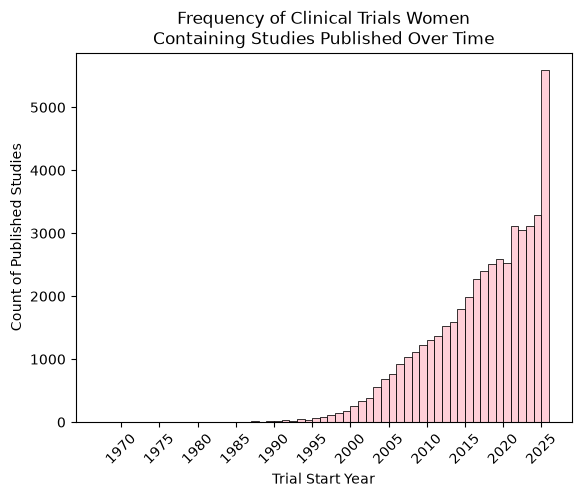

In [84]:
sns.histplot(ct_df[ct_df["contains_women"]], x = 'start_year', binwidth=1, color='pink')
plt.xticks(np.arange(1970, 2027, step = 5), rotation=45)
plt.xlabel("Trial Start Year")
plt.ylabel("Count of Published Studies")
plt.title("Frequency of Clinical Trials Women\nContaining Studies Published Over Time")
plt.show()

## Title and Summary EDA 

So upon EDA it has come to my attention that when filtering for female, women, woman, or girls, for summary and title, some studies sex is labeled as MALE, when either that study in question has only women particpants or both. 

Okay so looking further into this, it seems that studies can hve

In [15]:
ct_df['summary'].info()

<class 'pandas.Series'>
RangeIndex: 373282 entries, 0 to 373281
Series name: summary
Non-Null Count   Dtype
--------------   -----
373282 non-null  str  
dtypes: str(1)
memory usage: 258.5 MB


In [16]:
ct_df['title'].info()

<class 'pandas.Series'>
RangeIndex: 373282 entries, 0 to 373281
Series name: title
Non-Null Count   Dtype
--------------   -----
373282 non-null  str  
dtypes: str(1)
memory usage: 34.4 MB


In [17]:
pattern = r'\bfemales?\b|\bwomen\b|\bwoman\b|\bgirls?\b|\bshe\b|\bher\b|\bmothers?\b|\bladies?\b|\bwife\b|\bmoms?\b|\bdaughters?\b'

mask_summary = ct_df['summary'].str.contains(pattern, na = False, case = False)
mask_title = ct_df['title'].str.contains(pattern, na = False, case = False)

mask_combined = mask_summary | mask_title

In [18]:
ct_df[mask_combined].info()
# 35,335

<class 'pandas.DataFrame'>
Index: 35335 entries, 6 to 373263
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   nct_number       35335 non-null  str           
 1   title            35335 non-null  str           
 2   study_status     35335 non-null  str           
 3   summary          35335 non-null  str           
 4   conditions       35335 non-null  str           
 5   pom              34134 non-null  str           
 6   sponsor          35335 non-null  str           
 7   collaborators    12778 non-null  str           
 8   sex              35318 non-null  str           
 9   age              35335 non-null  str           
 10  enrollment       35049 non-null  float64       
 11  funder_type      35335 non-null  str           
 12  study_type       35335 non-null  str           
 13  start_date       35335 non-null  datetime64[us]
 14  completion_date  34654 non-null  datetime64[us]
 15  

In [19]:
ct_df[mask_combined]['summary'].head().tolist()

['To determine cardiovascular risk factors and the change in risk factors during and following the menopause.',
 'To continue a study of premature coronary heart disease mortality among men and women aged 35-54 in Allegheny County, Pennsylvania.',
 'This trial is conducted in Europe. The aim of this trial is to study the dose-response relationship and effect of somatropin (Norditropin®) on final height in girls with Turner Syndrome.',
 'Background:* Cancer has an enormous impact on the psychological and social well-being of the family unit. The life-threatening connotations of cancer single out the ill child from his peer/family group as one who is different, and often unable to maintain a normal lifestyle. Physical sequelae of cancer and its treatment accentuate the differences between these children and their normal peers/siblings.* It is important that children with cancer be prepared to function outside of protected situations and begin to develop skills of separation and independe

In [20]:
ct_df[mask_combined].head(2)

,nct_number,title,study_status,summary,conditions,pom,sponsor,collaborators,sex,age,enrollment,funder_type,study_type,start_date,completion_date,start_year,completion_year
6,NCT00005160,Epidemiology of Cardiovascular Risk Factors in...,COMPLETED,To determine cardiovascular risk factors and t...,Cardiovascular Diseases|Heart Diseases|Depress...,Predictors of coronary and aortic calcium and ...,University of Pittsburgh,"National Heart, Lung, and Blood Institute (NHLBI)",FEMALE,"ADULT, OLDER_ADULT",532.0,OTHER,OBSERVATIONAL,1983-04-01,2008-11-01,1983,2008.0
12,NCT00005162,Epidemiology of Decline in Heart Disease Morta...,COMPLETED,To continue a study of premature coronary hear...,Cardiovascular Diseases|Heart Diseases|Coronar...,NaN,"National Heart, Lung, and Blood Institute (NHLBI)",NaN,MALE,"CHILD, ADULT, OLDER_ADULT",NaN,NIH,OBSERVATIONAL,1983-08-01,1996-11-01,1983,1996.0


In [21]:
# Make a mask for sex
mask_sex = ct_df['sex'].isin(['FEMALE', 'ALL']) 

In [22]:
# Assign this mask to a new boolean column
# Combine this mask with when the sex columns is equal to female or all
ct_df['contains_women'] = mask_combined | mask_sex

In [23]:
ct_df[ct_df['contains_women'] == True].head(15)
# So there are instances where contains_women is true and sex is male

,nct_number,title,study_status,summary,conditions,pom,sponsor,collaborators,sex,age,enrollment,funder_type,study_type,start_date,completion_date,start_year,completion_year,contains_women
0,NCT00000503,Randomized Clinical Trial of Non-Surgical Repe...,COMPLETED,To assess the effect of non-surgical reperfusi...,Cardiovascular Diseases|Coronary Disease|Heart...,NaN,"National Heart, Lung, and Blood Institute (NHLBI)",NaN,ALL,"ADULT, OLDER_ADULT",NaN,NIH,INTERVENTIONAL,1982-08-01,1987-10-01,1982,1987.0,True
1,NCT00271180,Product Performance Report: Evaluate Long-term...,RECRUITING,The main purpose of the Product Performance Re...,Arrhythmia|Bradycardia|Heart Failure|Sinus Tac...,Lead related complications for each lead model...,Medtronic,NaN,ALL,"CHILD, ADULT, OLDER_ADULT",20000.0,INDUSTRY,OBSERVATIONAL,1983-01-01,2040-12-01,1983,2040.0,True
2,NCT00000511,Polyunsaturates and KCL to Control Mild Hypert...,COMPLETED,To test the efficacy of omega-3 fatty acids in...,Cardiovascular Diseases|Heart Diseases|Hyperte...,"Blood Pressure, 14 hour ambulatory BP, End of ...",Brigham and Women's Hospital,"National Heart, Lung, and Blood Institute (NHLBI)",ALL,"ADULT, OLDER_ADULT",NaN,OTHER,INTERVENTIONAL,1983-12-01,1994-11-01,1983,1994.0,True
6,NCT00005160,Epidemiology of Cardiovascular Risk Factors in...,COMPLETED,To determine cardiovascular risk factors and t...,Cardiovascular Diseases|Heart Diseases|Depress...,Predictors of coronary and aortic calcium and ...,University of Pittsburgh,"National Heart, Lung, and Blood Institute (NHLBI)",FEMALE,"ADULT, OLDER_ADULT",532.0,OTHER,OBSERVATIONAL,1983-04-01,2008-11-01,1983,2008.0,True
7,NCT00000585,Penicillin Prophylaxis in Sickle Cell Disease ...,COMPLETED,To determine whether the regular daily adminis...,"Anemia, Sickle Cell|Hematologic Diseases|Hemog...",NaN,"National Heart, Lung, and Blood Institute (NHLBI)",NaN,ALL,CHILD,NaN,NIH,INTERVENTIONAL,1983-08-01,1994-10-01,1983,1994.0,True
8,NCT00000510,Platelet-Inhibitor Drug Trial in Coronary Angi...,COMPLETED,To determine the effectiveness of dipyridamole...,Angina Pectoris|Cardiovascular Diseases|Corona...,NaN,"National Heart, Lung, and Blood Institute (NHLBI)",NaN,ALL,"ADULT, OLDER_ADULT",NaN,NIH,INTERVENTIONAL,1983-09-01,1988-09-01,1983,1988.0,True
9,NCT00000584,Transfusion-Transmitted Cytomegalovirus Preven...,COMPLETED,To evaluate the capacity of intravenously admi...,Blood Transfusion|Cytomegalovirus Infections,NaN,"National Heart, Lung, and Blood Institute (NHLBI)",NaN,ALL,CHILD,NaN,NIH,INTERVENTIONAL,1983-07-01,1988-06-01,1983,1988.0,True
11,NCT00222664,Qidong Hepatitis B Intervention Study,COMPLETED,During 1983-1990 in the Jiangsu province of Ch...,Hepatitis B|Liver Neoplasms|Liver Diseases,NaN,University of Oxford,"Cancer Institute and Hospital, Chinese Academy...",ALL,"CHILD, ADULT, OLDER_ADULT",80000.0,OTHER,INTERVENTIONAL,1983-09-01,2004-12-01,1983,2004.0,True
12,NCT00005162,Epidemiology of Decline in Heart Disease Morta...,COMPLETED,To continue a study of premature coronary hear...,Cardiovascular Diseases|Heart Diseases|Coronar...,NaN,"National Heart, Lung, and Blood Institute (NHLBI)",NaN,MALE,"CHILD, ADULT, OLDER_ADULT",NaN,NIH,OBSERVATIONAL,1983-08-01,1996-11-01,1983,1996.0,True
13,NCT00001188,The Role of Multi-Modality Therapy for the Tre...,COMPLETED,Patients with Grade II and III soft tissue sar...,Sarcoma,NaN,National Cancer Institute (NCI),NaN,ALL,"CHILD, ADULT, OLDER_ADULT",100.0,NIH,INTERVENTIONAL,1983-12-01,2000-09-01,1983,2000.0,True


## sex EDA 

After filtering for women keywords in the title and summary of the trials, it was found that most studies are labeled default as MALE fo eligible particapnts, even though the description of the study clearly states there are women participants. 

Some instances where this is true the mask search can not find a gender keyword in the title or summary, but it is in the description of the actual study on clinical trials.


<Axes: xlabel='sex', ylabel='Count'>

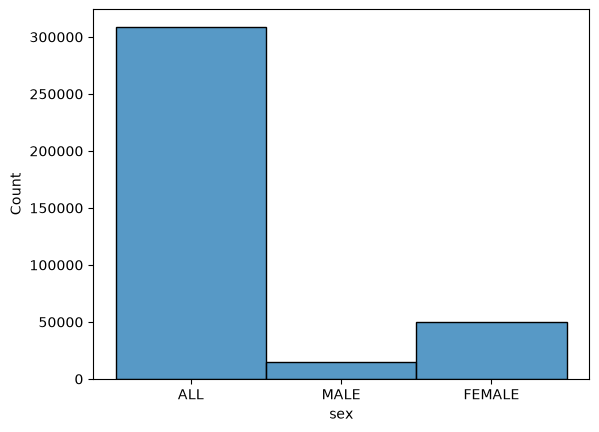

In [ ]:
sns.histplot(data = ct_df, x = 'sex')
# This makes sense as a lot of 

<Axes: xlabel='sex', ylabel='Count'>

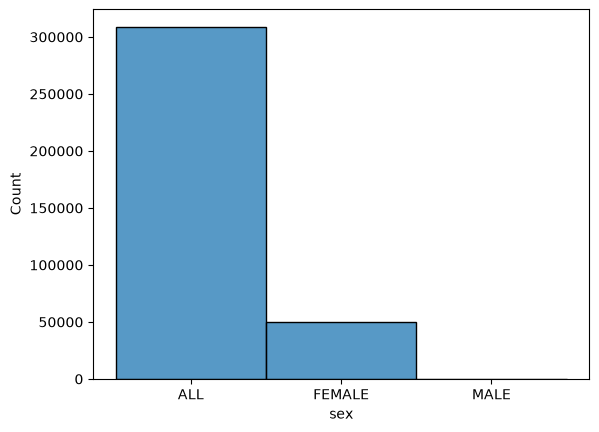

In [136]:
sns.histplot(data = ct_df[ct_df['contains_women']], x = 'sex')

In [145]:
ct_df[ct_df['contains_women'] == True]['sex'].value_counts()

sex
ALL       308739
FEMALE     49911
MALE         335
Name: count, dtype: int64

In [ ]:
ct_df['study_status'].unique()
# How many womens study are being terminated versus other 

<ArrowStringArray>
[              'COMPLETED',              'RECRUITING',
                 'UNKNOWN',              'TERMINATED',
   'ACTIVE_NOT_RECRUITING',               'WITHDRAWN',
 'ENROLLING_BY_INVITATION',               'SUSPENDED',
     'NO_LONGER_AVAILABLE',  'APPROVED_FOR_MARKETING',
               'AVAILABLE',      'NOT_YET_RECRUITING']
Length: 12, dtype: str

# Reddit Clinical Trials Data

In [12]:
cf = pd.read_csv("reddit_clinical_trials_data.csv")

In [3]:
cf.info()
# 159,933 rows

<class 'pandas.DataFrame'>
RangeIndex: 159934 entries, 0 to 159933
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   nct_number       159934 non-null  str    
 1   title            159934 non-null  str    
 2   study_status     159934 non-null  str    
 3   summary          159934 non-null  str    
 4   conditions       159934 non-null  str    
 5   pom              157440 non-null  str    
 6   sponsor          159934 non-null  str    
 7   collaborators    56321 non-null   str    
 8   sex              159873 non-null  str    
 9   age              159934 non-null  str    
 10  enrollment       159469 non-null  float64
 11  funder_type      159934 non-null  str    
 12  study_type       159934 non-null  str    
 13  start_date       159934 non-null  str    
 14  completion_date  157913 non-null  str    
 15  keyword          159934 non-null  str    
 16  start_year       159934 non-null  int64  
 17  co

## The two different datasets

### 1. Duplicate rows: Every paper has multiple keywords (this is the original dataset)

In [13]:
cf_k = cf

In [14]:
cf_k = cf_k.drop(columns=['nct_number', 
                          'study_status', 
                          'summary', 
                          'conditions', 
                          'pom', 
                          'sponsor',
                          'collaborators',
                          'sex', 
                          'age', 
                          'enrollment', 
                          'funder_type', 
                          'study_type', 
                          'start_date', 
                          'completion_date', 
                          'completion_year'])

In [15]:
cf_k

,title,keyword,start_year
0,Northern Sweden Health and Disease Study,mammography,1986
1,Epidemiology of Sleep Apnea Syndrome,sleep disturbance,1986
2,Effectiveness of AIDS Antibody Screening,sexually transmitted infection,1986
3,Effectiveness of AIDS Antibody Screening,STI,1986
4,Prediction and Testing of Antigenic Sites of t...,sexually transmitted infection,1986
...,...,...,...
159929,Clinical Trial of Eye Prophylaxis in the Newborn,sexually transmitted infection,1985
159930,Clinical Trial of Eye Prophylaxis in the Newborn,STI,1985
159931,Determination of Adipocyte Parameters in Iliac...,menopause hormone therapy,1985
159932,Natural History of Treated Neurocysticercosis ...,headache,1985


### To warehouse

In [16]:
# Connect to the database
conn = psycopg2.connect(
    dbname=os.getenv("DBNAME"),
    user=os.getenv("DBUSER"),
    password=os.getenv("DBPASSWORD"),
    port=os.getenv("DBPORT"),
    host=os.getenv("DBHOST")
)
conn_string=os.getenv("CONNSTRING")

# Create engine
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DBUSER')}:{os.getenv('DBPASSWORD')}"
    f"@{os.getenv('DBHOST')}:{os.getenv('DBPORT')}/{os.getenv('DBNAME')}"
)

In [17]:
cf_k.to_sql("clinical_trials_key", engine, if_exists="append", index=False, method="multi", chunksize=300)

159934

### 2. Unique rows for each paper: Keywords are in a list

In [18]:
cf.duplicated(subset='nct_number').sum()

np.int64(58392)

In [19]:
cf[['nct_number']].value_counts()

nct_number 
NCT05837624    18
NCT07169292    18
NCT04256200    16
NCT07037082    16
NCT00038467    15
               ..
NCT00005283     1
NCT00001197     1
NCT00443716     1
NCT00001205     1
NCT00005184     1
Name: count, Length: 101542, dtype: int64

In [20]:
cf[cf['nct_number'] == 'NCT05837624'].head(5)

,nct_number,title,study_status,summary,conditions,pom,sponsor,collaborators,sex,age,enrollment,funder_type,study_type,start_date,completion_date,keyword,start_year,completion_year
136712,NCT05837624,Estetrol/Drospirenone to Reduce the Average Si...,RECRUITING,"Endometriosis, a chronic gynecological disorde...",Ovarian Endometrioma|Endometrioma,Change in ovarian endometrioma volume at 6-mon...,Andrew Zakhari,NaN,FEMALE,"ADULT, OLDER_ADULT",21.0,OTHER,INTERVENTIONAL,2024-12-03,2026-12-01,dysmenorrhea,2024,2026.0
136718,NCT05837624,Estetrol/Drospirenone to Reduce the Average Si...,RECRUITING,"Endometriosis, a chronic gynecological disorde...",Ovarian Endometrioma|Endometrioma,Change in ovarian endometrioma volume at 6-mon...,Andrew Zakhari,NaN,FEMALE,"ADULT, OLDER_ADULT",21.0,OTHER,INTERVENTIONAL,2024-12-03,2026-12-01,period cramps,2024,2026.0
136724,NCT05837624,Estetrol/Drospirenone to Reduce the Average Si...,RECRUITING,"Endometriosis, a chronic gynecological disorde...",Ovarian Endometrioma|Endometrioma,Change in ovarian endometrioma volume at 6-mon...,Andrew Zakhari,NaN,FEMALE,"ADULT, OLDER_ADULT",21.0,OTHER,INTERVENTIONAL,2024-12-03,2026-12-01,amenorrhea,2024,2026.0
136726,NCT05837624,Estetrol/Drospirenone to Reduce the Average Si...,RECRUITING,"Endometriosis, a chronic gynecological disorde...",Ovarian Endometrioma|Endometrioma,Change in ovarian endometrioma volume at 6-mon...,Andrew Zakhari,NaN,FEMALE,"ADULT, OLDER_ADULT",21.0,OTHER,INTERVENTIONAL,2024-12-03,2026-12-01,breakthrough bleeding,2024,2026.0
136728,NCT05837624,Estetrol/Drospirenone to Reduce the Average Si...,RECRUITING,"Endometriosis, a chronic gynecological disorde...",Ovarian Endometrioma|Endometrioma,Change in ovarian endometrioma volume at 6-mon...,Andrew Zakhari,NaN,FEMALE,"ADULT, OLDER_ADULT",21.0,OTHER,INTERVENTIONAL,2024-12-03,2026-12-01,intermenstrual bleeding,2024,2026.0


In [21]:
cf_g = cf.groupby(['nct_number'], as_index = False, sort = False, dropna = False).agg({'pom':'first', 
                                                                                       'sponsor':'first', 
                                                                                       'collaborators':'first', 
                                                                                       'sex':'first', 
                                                                                       'age':'first', 
                                                                                       'enrollment':'first',
                                                                                       'funder_type':'first',
                                                                                       'study_type':'first',
                                                                                       'start_date':'first',
                                                                                       'completion_date':'first',
                                                                                       'keyword': lambda x: list(x.dropna().unique()),
                                                                                       'start_year':'first',
                                                                                       'completion_year':'first'
                                                                                       })

In [22]:
cf_g

,nct_number,pom,sponsor,collaborators,sex,age,enrollment,funder_type,study_type,start_date,completion_date,keyword,start_year,completion_year
0,NCT03426488,"Number of deaths, Follow up at least 20 years|...",Umeå University,NaN,ALL,"CHILD, ADULT, OLDER_ADULT",120000.0,OTHER,OBSERVATIONAL,1986-01-01,2026-01-01,[mammography],1986,2026.0
1,NCT00005286,NaN,University of New Mexico,"National Heart, Lung, and Blood Institute (NHLBI)",MALE,"CHILD, ADULT, OLDER_ADULT",NaN,OTHER,OBSERVATIONAL,1986-04-01,1989-03-01,[sleep disturbance],1986,1989.0
2,NCT00005303,NaN,"National Heart, Lung, and Blood Institute (NHLBI)",NaN,MALE,"CHILD, ADULT, OLDER_ADULT",NaN,NIH,OBSERVATIONAL,1986-09-01,1995-09-01,"[sexually transmitted infection, STI]",1986,1995.0
3,NCT00001210,NaN,National Cancer Institute (NCI),NaN,ALL,"CHILD, ADULT, OLDER_ADULT",60.0,NIH,OBSERVATIONAL,1986-11-01,2000-09-01,"[sexually transmitted infection, STI]",1986,2000.0
4,NCT00001212,Time to complete or partial remission of prote...,National Institute of Diabetes and Digestive a...,NaN,ALL,"CHILD, ADULT, OLDER_ADULT",45.0,NIH,INTERVENTIONAL,1986-11-01,2004-09-01,[pregnancy test],1986,2004.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101537,NCT00005301,NaN,"National Heart, Lung, and Blood Institute (NHLBI)",NaN,MALE,"CHILD, ADULT, OLDER_ADULT",NaN,NIH,OBSERVATIONAL,1984-09-01,1998-02-01,"[sexually transmitted infection, STI]",1984,1998.0
101538,NCT00000120,NaN,National Eye Institute (NEI),NaN,ALL,CHILD,NaN,NIH,INTERVENTIONAL,1985-01-01,NaN,"[sexually transmitted infection, STI]",1985,NaN
101539,NCT00443716,efficacy of estraderm treatment on osteoporoti...,Mayo Clinic,NaN,FEMALE,"ADULT, OLDER_ADULT",60.0,OTHER,INTERVENTIONAL,1985-04-01,1989-04-01,[menopause hormone therapy],1985,1989.0
101540,NCT00001205,The primary objective is to characterize the b...,National Institute of Allergy and Infectious D...,NaN,ALL,"CHILD, ADULT, OLDER_ADULT",500.0,NIH,OBSERVATIONAL,1985-10-07,NaN,[headache],1985,NaN


### To CSV

In [23]:
cf_g.to_csv('key_clinical_trials.csv')

## Counts of Sex

<Axes: xlabel='sex', ylabel='count'>

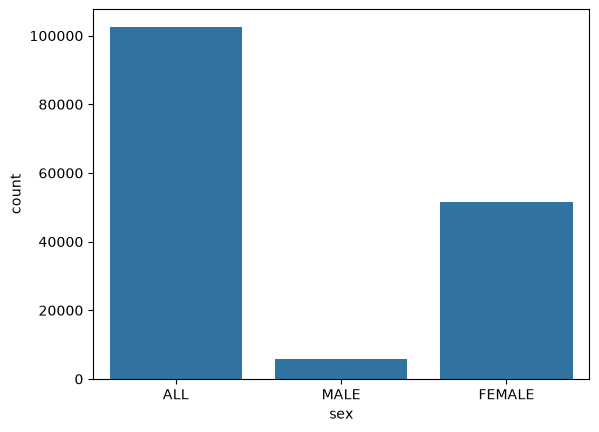

In [6]:
sns.countplot(x='sex',data=cf)

## What keywords did not get pulled at all?

All of them got pulled!

In [ ]:
cf['keyword'].nunique()

84

## Top 10 Most Published Keywords

In [8]:
cf['keyword'].value_counts()

keyword
fatigue                           22347
pregnancy test                    14665
nausea                            13646
sleep disturbance                 13113
headache                           8124
                                  ...  
ovarian torsion                      41
fibroadenoma                         39
birth control and libido             35
boric acid vaginal suppository        3
Bartholin cyst                        3
Name: count, Length: 84, dtype: int64

In [9]:
cf['keyword'].value_counts().head(10)

keyword
fatigue                           22347
pregnancy test                    14665
nausea                            13646
sleep disturbance                 13113
headache                           8124
STI                                7325
sexually transmitted infection     7268
allergic                           4983
HRT                                4869
pelvic pain                        3891
Name: count, dtype: int64

## Top 10 Least Published Keywords

In [10]:
cf['keyword'].value_counts().tail(10)

keyword
probiotics vaginal health         106
tubal ligation                     73
progestin-only pill                59
hormonal acne                      56
recurrent yeast infection          55
ovarian torsion                    41
fibroadenoma                       39
birth control and libido           35
boric acid vaginal suppository      3
Bartholin cyst                      3
Name: count, dtype: int64

## Publications Over the Years

In [11]:
(cf['start_year'] == 2026).sum()

np.int64(9263)

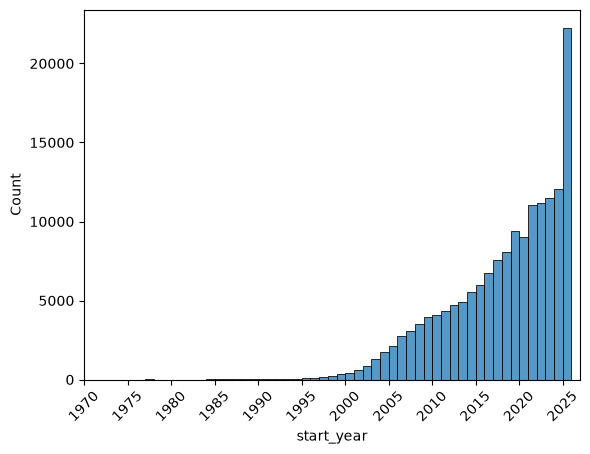

In [12]:
sns.histplot(cf, x='start_year', binwidth=1)
plt.xlim(1970, 2027)
plt.xticks(np.arange(1970, 2027, step = 5), rotation=45)
plt.show()

## Publications Since 2000

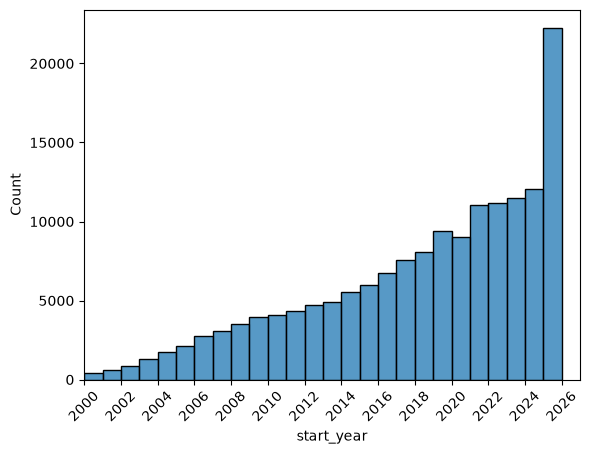

In [13]:
years = np.arange(2000, 2027)
sns.histplot(cf, x='start_year', bins=years)
plt.xlim(2000, 2027)
plt.xticks(np.arange(2000, 2027, step = 2), rotation=45)
plt.show()

## Study Status

In [14]:
cf['study_status'].value_counts()

study_status
COMPLETED                  87381
UNKNOWN                    22547
RECRUITING                 20199
NOT_YET_RECRUITING          9036
TERMINATED                  8498
ACTIVE_NOT_RECRUITING       6442
WITHDRAWN                   3819
ENROLLING_BY_INVITATION     1552
SUSPENDED                    442
NO_LONGER_AVAILABLE           10
APPROVED_FOR_MARKETING         8
Name: count, dtype: int64